In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout



In [10]:

# ==========================================
# ধাপ ১: ডেটা সংগ্রহ করা
# ==========================================
print("ডেটা ডাউনলোড হচ্ছে...")
# Apple-এর গত কয়েক বছরের ডেটা নিচ্ছি, GOOGL, TSLA
data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')

# আমরা শুধু 'Close' প্রাইস বা দিনের শেষের দাম নিয়ে কাজ করব
dataset = data['Close'].values
dataset = dataset.reshape(-1, 1) # 2D অ্যারে-তে রূপান্তর


/tmp/ipykernel_876/3091170130.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed

ডেটা ডাউনলোড হচ্ছে...


In [4]:

# ==========================================
# ধাপ ২: ডেটা প্রসেসিং (Scaling)
# ==========================================
# LSTM মডেল ০ থেকে ১ এর ভেতরের সংখ্যা খুব ভালো বোঝে
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# ট্রেনিং ডেটার সাইজ ঠিক করা (৮০% ডেটা দিয়ে ট্রেইন করব)
training_data_len = int(np.ceil(len(dataset) * .8))
train_data = scaled_data[0:int(training_data_len), :]

# স্লাইডিং উইন্ডো (Sliding Window): গত ৬০ দিনের ডেটা দেখে ৬১ তম দিনের দাম প্রেডিক্ট করব
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

# LSTM 3D ডেটা সাপোর্ট করে, তাই Reshape করা হচ্ছে [samples, time steps, features]
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


In [5]:
# ==========================================
# ধাপ ৩: LSTM মডেল তৈরি করা
# ==========================================
print("মডেল তৈরি হচ্ছে...")
model = Sequential()

# প্রথম LSTM লেয়ার এবং Dropout
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2)) # ২০% নিউরন বন্ধ রাখব যাতে মডেল মুখস্থ না করে (Overfitting রোধ)

# দ্বিতীয় LSTM লেয়ার
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# আউটপুট লেয়ার (চূড়ান্ত দাম প্রেডিক্ট করার জন্য)
model.add(Dense(units=25))
model.add(Dense(units=1))

# মডেল কম্পাইল করা
model.compile(optimizer='adam', loss='mean_squared_error')

মডেল তৈরি হচ্ছে...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# ==========================================
# ধাপ ৪: মডেল ট্রেনিং
# ==========================================
print("মডেল ট্রেনিং শুরু হচ্ছে... (কিছুটা সময় লাগতে পারে)")
model.fit(x_train, y_train, batch_size=32, epochs=10) # epochs=10 মানে মডেলটি ১০ বার পুরো ডেটা পড়বে

# ==========================================
# ধাপ ৫: টেস্টিং ডেটা প্রস্তুত করা
# ==========================================
test_data = scaled_data[training_data_len - 60: , :]
x_test = []
y_test = dataset[training_data_len:, :] # আসল দাম

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

মডেল ট্রেনিং শুরু হচ্ছে... (কিছুটা সময় লাগতে পারে)
Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.2694e-04
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.4888e-04
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.4611e-04
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.5457e-04
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.6058e-04
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.6399e-04
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.6180e-04
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.2615e-04
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.5551e-04
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.3841e-04


In [8]:
# ==========================================
# ধাপ ৬: প্রেডিকশন এবং ভিজ্যুয়ালাইজেশন
# ==========================================
print("ভবিষ্যদ্বাণী (Prediction) করা হচ্ছে...")
predictions = model.predict(x_test)
# স্কেল করা মানগুলোকে আবার আসল ডলারের দামে ফিরিয়ে আনা
predictions = scaler.inverse_transform(predictions)

ভবিষ্যদ্বাণী (Prediction) করা হচ্ছে...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


/tmp/ipykernel_876/109600799.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


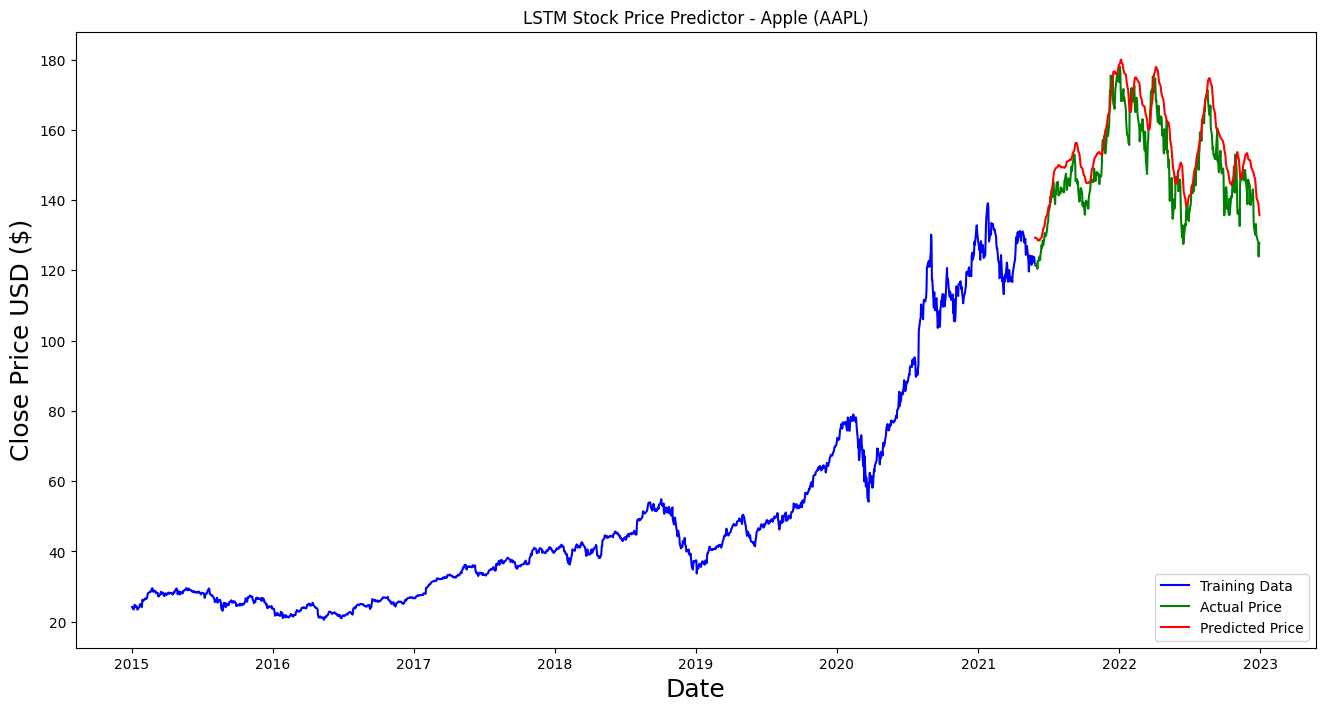

In [9]:

# গ্রাফ আঁকার জন্য ডেটা সাজানো
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

# সুন্দর একটি গ্রাফ তৈরি করা
plt.figure(figsize=(16,8))
plt.title('LSTM Stock Price Predictor - Apple (AAPL)')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'], color='blue', label='Training Data')
plt.plot(valid['Close'], color='green', label='Actual Price')
plt.plot(valid['Predictions'], color='red', label='Predicted Price')
plt.legend(loc='lower right')
plt.show()